In [ ]:
import os
from collections import Counter
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt

from eval_genome import test_genome_mp
import eval_genome
eval_genome.METRIC = 'ttd'

In [12]:
def test_genome_against_n(genome: tuple[float, float, float, float], rng_seed=20, samples=10, n_range=[]):
    results: list[dict] = []
    for n in n_range:
        stats, _rate = test_genome_mp(genome, n, rng_seed=rng_seed, trials=samples)
        print('n: ', n, sum(stats, Counter()))

        for stat in stats:
            results.append({
                "n": n,
                **stat
            })

    return results

In [13]:
n_range = [
    *range(6, 10),
    # *range(10, 30, 2),
    # *range(30, 100+1, 5),
]

results = test_genome_against_n(
    (0.2, 0.2, 0.2, -0.2),
    n_range=n_range
)

  0%|          | 0/10 [00:00<?, ?it/s]

n:  6 Counter({'Time to Detect sub': 1133, 'Time to Capture': 10, 'How many red on goal': 10})


  0%|          | 0/10 [00:00<?, ?it/s]

n:  7 Counter({'Time to Detect sub': 1133, 'Time to Capture': 10, 'How many red on goal': 10})


  0%|          | 0/10 [00:00<?, ?it/s]

n:  8 Counter({'Time to Detect sub': 1133, 'Time to Capture': 10, 'How many red on goal': 10})


  0%|          | 0/10 [00:00<?, ?it/s]

n:  9 Counter({'Time to Detect sub': 1127, 'Time to Capture sub': 217, 'Time to Capture': 9, 'How many red on goal': 9})


In [14]:
df = pd.DataFrame.from_dict(results)
df

,n,Time to Capture,Time to Detect sub,Time to Capture sub,How many red on goal
0,6,1,-1,-1,1
1,6,1,-1,-1,1
2,6,1,197,-1,1
3,6,1,155,-1,1
4,6,1,-1,-1,1
5,6,1,-1,-1,1
6,6,1,210,-1,1
7,6,1,111,-1,1
8,6,1,247,-1,1
9,6,1,215,-1,1


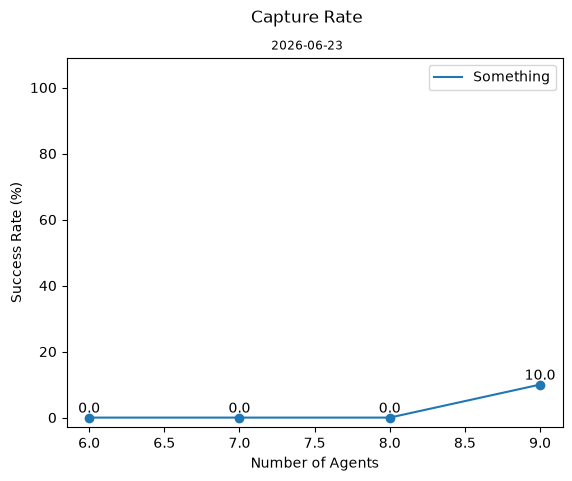

In [15]:
def srate(df, name='Success'):
    x = (100 - df.groupby(['n'])['How many red on goal'].mean() * 100).round().rename(f'{name} Rate')
    return x.index, x


plt.plot(*srate(df), label='Something')
plt.legend()
plt.scatter(*srate(df))

dt_title = dt.datetime.now().strftime("%Y-%m-%d")
plt.title(dt_title, size='small', x=0.485)
plt.suptitle(f"{'Capture' if eval_genome.METRIC == 'ttc' else 'Detection'} Rate")
plt.xlabel('Number of Agents')
plt.ylabel('Success Rate (%)')
margin = 3
plt.ylim(0 - margin, 100 + 3 * margin)

for n, sr in zip(*srate(df)):
    plt.text(n, sr + 0.5, str(sr), ha="center", va="bottom")
